# 01. Mediation Analysis

Many causal projects start with a total effect:

> Did the intervention change the outcome?

Mediation analysis asks a deeper mechanism question:

> How much of the effect operated through a specific intermediate variable?

This is powerful, but it is also dangerous. A randomized treatment does not automatically make the mediator as-if randomized. Once we condition on or model a post-treatment mediator, we are making additional assumptions about the mediator-outcome relationship.

This notebook develops mediation analysis from potential outcomes, diagrams, simulations, and reporting practice. We will estimate direct and indirect effects in a clean linear setting, use g-computation for nonlinear mediation with interactions, and show how unmeasured mediator-outcome confounding can distort the story.


## Learning Goals

By the end of this notebook, you should be able to:

- Distinguish total effects, controlled direct effects, natural direct effects, and natural indirect effects.
- Explain why mediation requires stronger assumptions than estimating an ATE.
- Estimate mediation effects in a simple linear setting.
- Use g-computation to estimate mediation effects when models are nonlinear or include interactions.
- Diagnose why "adjusting for the mediator" is not a generic solution.
- Explain how unmeasured mediator-outcome confounding biases mediation analysis.
- Write a careful mediation readout that does not overclaim mechanism.


## 1. Setup

We will use pandas, numpy, statsmodels, scipy, seaborn, matplotlib, and Graphviz.


In [1]:
import warnings
warnings.filterwarnings("ignore")

from graphviz import Digraph
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.special import expit
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


def regression_effect(model, term):
    estimate = model.params[term]
    se = model.bse[term]
    return pd.Series(
        {
            "estimate": estimate,
            "std_error": se,
            "ci_lower": estimate - 1.96 * se,
            "ci_upper": estimate + 1.96 * se,
            "p_value": model.pvalues[term],
        }
    )


def plot_coef_table(table, title, xlabel, reference=0, figsize=(8.5, 4.5)):
    plot_df = table.sort_values("estimate")
    fig, ax = plt.subplots(figsize=figsize)
    ax.errorbar(
        x=plot_df["estimate"],
        y=plot_df.index,
        xerr=[
            plot_df["estimate"] - plot_df["ci_lower"],
            plot_df["ci_upper"] - plot_df["estimate"],
        ],
        fmt="o",
        color="#2b8cbe",
        ecolor="#a6bddb",
        elinewidth=3,
        capsize=4,
    )
    ax.axvline(reference, color="#444444", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    plt.tight_layout()
    return fig, ax


## 2. From "Does It Work?" to "How Does It Work?"

Suppose a company launches an onboarding intervention:

- treatment: proactive onboarding call,
- mediator: product activation in the first 7 days,
- outcome: renewal or 90-day net revenue.

The total effect asks whether assignment to onboarding changed renewal. Mediation asks whether that effect operated through activation.

The basic causal story is:


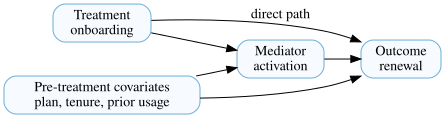

In [2]:
dot = Digraph("simple_mediation", graph_attr={"rankdir": "LR"})
dot.attr("node", shape="box", style="rounded,filled", fillcolor="#f7fbff", color="#6baed6")

dot.node("T", "Treatment\nonboarding")
dot.node("M", "Mediator\nactivation")
dot.node("Y", "Outcome\nrenewal")
dot.node("X", "Pre-treatment covariates\nplan, tenure, prior usage")

dot.edge("T", "M")
dot.edge("M", "Y")
dot.edge("T", "Y", label="direct path")
dot.edge("X", "M")
dot.edge("X", "Y")

dot


Mediation analysis is not just a model with an extra variable. It is a causal question about pathways.

Imai, Keele, and Tingley (2010) emphasize that causal mediation requires definitions, identification assumptions, estimation, and sensitivity analysis. Robins and Greenland (1992) showed that simply adjusting for an intermediate variable can be biased when trying to separate direct and indirect effects.


## 3. Potential Outcomes Notation

Let:

- $T_i$ be treatment assignment,
- $M_i(t)$ be the mediator value unit $i$ would have under treatment $t$,
- $Y_i(t,m)$ be the outcome unit $i$ would have under treatment $t$ and mediator value $m$.

The observed mediator is:

$$
M_i = M_i(T_i)
$$

The observed outcome is:

$$
Y_i = Y_i(T_i, M_i(T_i))
$$

The total effect is:

$$
TE = E[Y_i(1, M_i(1)) - Y_i(0, M_i(0))]
$$

The natural indirect effect under treatment is:

$$
NIE(1) = E[Y_i(1, M_i(1)) - Y_i(1, M_i(0))]
$$

The natural direct effect holding the mediator at its control value is:

$$
NDE(0) = E[Y_i(1, M_i(0)) - Y_i(0, M_i(0))]
$$

These two pieces add to the total effect:

$$
TE = NDE(0) + NIE(1)
$$

This notation reveals the challenge: $Y_i(1, M_i(0))$ mixes treatment status from one world with the mediator value from another world. These are sometimes called cross-world counterfactuals.


In [3]:
estimand_table = pd.DataFrame(
    [
        {
            "estimand": "Total effect",
            "notation": "E[Y(1,M(1)) - Y(0,M(0))]",
            "question": "What is the overall effect of treatment?",
            "practical_reading": "Did the intervention work?",
        },
        {
            "estimand": "Controlled direct effect",
            "notation": "E[Y(1,m) - Y(0,m)]",
            "question": "What if we set the mediator to a fixed value m for everyone?",
            "practical_reading": "Effect of treatment if the mechanism is externally held fixed.",
        },
        {
            "estimand": "Natural direct effect",
            "notation": "E[Y(1,M(0)) - Y(0,M(0))]",
            "question": "What treatment effect remains if the mediator stayed at its control value?",
            "practical_reading": "Pathway not through the mediator.",
        },
        {
            "estimand": "Natural indirect effect",
            "notation": "E[Y(1,M(1)) - Y(1,M(0))]",
            "question": "How much effect comes from treatment changing the mediator?",
            "practical_reading": "Pathway through the mediator.",
        },
    ]
)

estimand_table


,estimand,notation,question,practical_reading
0,Total effect,"E[Y(1,M(1)) - Y(0,M(0))]",What is the overall effect of treatment?,Did the intervention work?
1,Controlled direct effect,"E[Y(1,m) - Y(0,m)]",What if we set the mediator to a fixed value m...,Effect of treatment if the mechanism is extern...
2,Natural direct effect,"E[Y(1,M(0)) - Y(0,M(0))]",What treatment effect remains if the mediator ...,Pathway not through the mediator.
3,Natural indirect effect,"E[Y(1,M(1)) - Y(1,M(0))]",How much effect comes from treatment changing ...,Pathway through the mediator.


## 4. Identification Assumptions

Randomizing treatment is enough to estimate the total effect. It is not enough to identify natural direct and indirect effects.

A common identification condition is **sequential ignorability**:

1. Treatment is as-if randomized conditional on pre-treatment covariates $X$.
2. The mediator is as-if randomized conditional on treatment and pre-treatment covariates $X$.

Informally:

$$
T \perp \{Y(t,m), M(t)\} \mid X
$$

and:

$$
M \perp Y(t,m) \mid T, X
$$

The second condition is the fragile one. It rules out unmeasured mediator-outcome confounding.


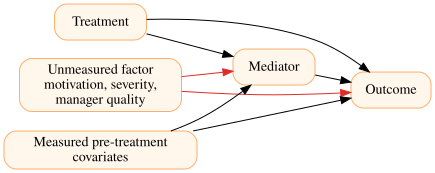

In [4]:
dot = Digraph("bad_mediation", graph_attr={"rankdir": "LR"})
dot.attr("node", shape="box", style="rounded,filled", fillcolor="#fff7ec", color="#fdae6b")

dot.node("T", "Treatment")
dot.node("M", "Mediator")
dot.node("Y", "Outcome")
dot.node("U", "Unmeasured factor\nmotivation, severity,\nmanager quality")
dot.node("X", "Measured pre-treatment\ncovariates")

dot.edge("T", "M")
dot.edge("M", "Y")
dot.edge("T", "Y")
dot.edge("X", "M")
dot.edge("X", "Y")
dot.edge("U", "M", color="#de2d26")
dot.edge("U", "Y", color="#de2d26")

dot


If $U$ affects both the mediator and outcome, then the mediator-outcome relationship is confounded. Even if treatment is randomized, the mediation decomposition can be wrong.


## 5. Simulation 1: Clean Linear Mediation

We start with the cleanest case:

- treatment is randomized,
- pre-treatment covariate $X$ affects both mediator and outcome,
- there is no unmeasured mediator-outcome confounding,
- mediator and outcome are continuous,
- the outcome model is linear with no treatment-mediator interaction.

The data generating process is:

$$
M = \alpha_0 + aT + \alpha_X X + \epsilon_M
$$

$$
Y = \beta_0 + c'T + bM + \beta_X X + \epsilon_Y
$$

The indirect effect is:

$$
ab
$$

The direct effect is:

$$
c'
$$


In [5]:
def simulate_linear_mediation(seed=123, n=6000):
    rng = np.random.default_rng(seed)
    x = rng.normal(0, 1, size=n)
    treatment = rng.binomial(1, 0.5, size=n)
    mediator = 0.4 + 0.85 * treatment + 0.65 * x + rng.normal(0, 1.0, size=n)
    outcome = 2.0 + 1.15 * treatment + 1.55 * mediator + 0.55 * x + rng.normal(0, 1.2, size=n)
    return pd.DataFrame(
        {
            "x": x,
            "treatment": treatment,
            "mediator": mediator,
            "outcome": outcome,
        }
    )


df_linear = simulate_linear_mediation()
df_linear.head()


,x,treatment,mediator,outcome
0,-0.989,0,-0.202,0.609
1,-0.368,0,0.091,2.471
2,1.288,1,2.027,8.431
3,0.194,1,0.286,3.144
4,0.920,0,1.039,3.921


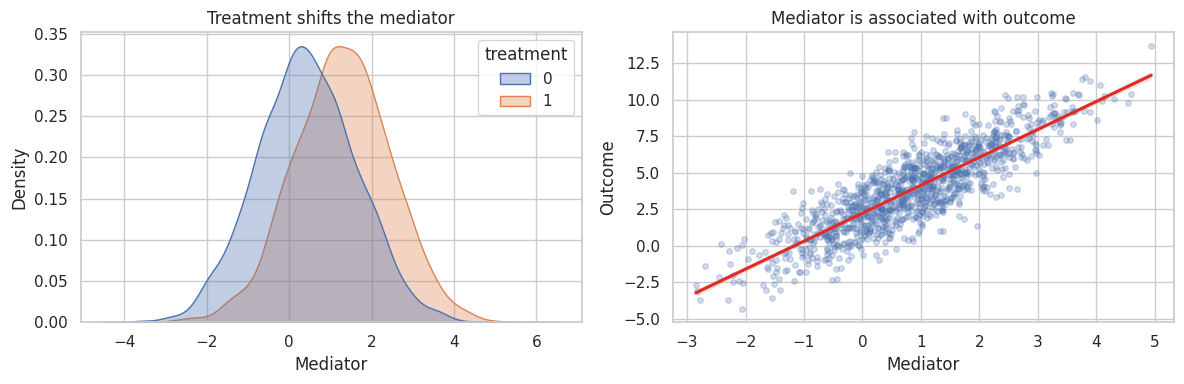

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.kdeplot(
    data=df_linear,
    x="mediator",
    hue="treatment",
    fill=True,
    common_norm=False,
    alpha=0.35,
    ax=axes[0],
)
axes[0].set_title("Treatment shifts the mediator")
axes[0].set_xlabel("Mediator")

sns.regplot(
    data=df_linear.sample(1200, random_state=1),
    x="mediator",
    y="outcome",
    scatter_kws={"alpha": 0.25, "s": 16},
    line_kws={"color": "#de2d26"},
    ax=axes[1],
)
axes[1].set_title("Mediator is associated with outcome")
axes[1].set_xlabel("Mediator")
axes[1].set_ylabel("Outcome")

plt.tight_layout()
plt.show()


Two empirical facts are necessary but not sufficient:

1. treatment changes the mediator,
2. the mediator predicts the outcome.

Mediation analysis additionally needs a causal claim about the mediator-outcome link.


In [7]:
mediator_model = smf.ols("mediator ~ treatment + x", data=df_linear).fit(cov_type="HC1")
outcome_model = smf.ols("outcome ~ treatment + mediator + x", data=df_linear).fit(cov_type="HC1")
total_model = smf.ols("outcome ~ treatment + x", data=df_linear).fit(cov_type="HC1")

a_hat = mediator_model.params["treatment"]
b_hat = outcome_model.params["mediator"]
direct_hat = outcome_model.params["treatment"]
indirect_hat = a_hat * b_hat
total_hat = total_model.params["treatment"]

linear_decomposition = pd.DataFrame(
    [
        {"quantity": "a: treatment -> mediator", "estimate": a_hat},
        {"quantity": "b: mediator -> outcome", "estimate": b_hat},
        {"quantity": "Indirect effect a*b", "estimate": indirect_hat},
        {"quantity": "Direct effect c'", "estimate": direct_hat},
        {"quantity": "Direct + indirect", "estimate": direct_hat + indirect_hat},
        {"quantity": "Total effect", "estimate": total_hat},
    ]
).set_index("quantity")

linear_decomposition


,estimate
quantity,
a: treatment -> mediator,0.855
b: mediator -> outcome,1.549
Indirect effect a*b,1.325
Direct effect c',1.140
Direct + indirect,2.465
Total effect,2.465


In this clean linear setting, the product-of-coefficients estimate recovers the indirect effect well. The direct plus indirect effect should be close to the total effect.


In [8]:
true_values = pd.Series(
    {
        "True indirect effect": 0.85 * 1.55,
        "True direct effect": 1.15,
        "True total effect": 1.15 + 0.85 * 1.55,
    }
)

true_values


True indirect effect   1.317
True direct effect     1.150
True total effect      2.467
dtype: float64

## 6. Bootstrap Uncertainty for the Mediation Decomposition

The indirect effect is a product of two estimated coefficients. A simple and common way to quantify uncertainty is the bootstrap.


In [9]:
def fit_linear_mediation(data):
    m_model = smf.ols("mediator ~ treatment + x", data=data).fit()
    y_model = smf.ols("outcome ~ treatment + mediator + x", data=data).fit()
    total = smf.ols("outcome ~ treatment + x", data=data).fit()
    a = m_model.params["treatment"]
    b = y_model.params["mediator"]
    direct = y_model.params["treatment"]
    indirect = a * b
    return pd.Series(
        {
            "Indirect effect": indirect,
            "Direct effect": direct,
            "Total effect": total.params["treatment"],
            "Proportion mediated": indirect / total.params["treatment"],
        }
    )


rng = np.random.default_rng(2026)
boot_rows = []
n = len(df_linear)
for _ in range(350):
    idx = rng.integers(0, n, size=n)
    boot_rows.append(fit_linear_mediation(df_linear.iloc[idx]))

boot = pd.DataFrame(boot_rows)
summary = boot.quantile([0.025, 0.5, 0.975]).T
summary.columns = ["ci_lower", "median", "ci_upper"]
summary["point_estimate"] = fit_linear_mediation(df_linear)
summary = summary[["point_estimate", "ci_lower", "median", "ci_upper"]]
summary


,point_estimate,ci_lower,median,ci_upper
Indirect effect,1.325,1.248,1.322,1.410
Direct effect,1.140,1.065,1.141,1.212
Total effect,2.465,2.356,2.464,2.560
Proportion mediated,0.537,0.518,0.536,0.563


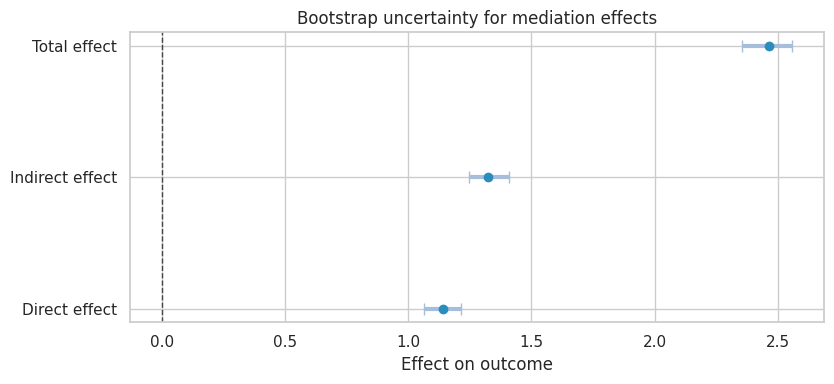

In [10]:
plot_table = summary.rename(columns={"point_estimate": "estimate"}).drop(index="Proportion mediated")
plot_coef_table(
    plot_table,
    title="Bootstrap uncertainty for mediation effects",
    xlabel="Effect on outcome",
    figsize=(8.5, 4),
)
plt.show()


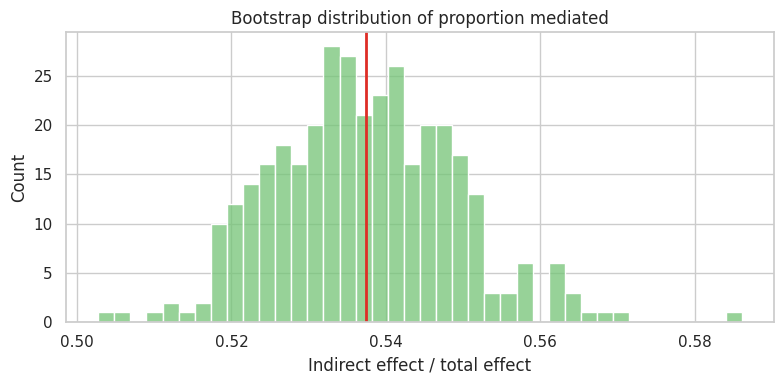

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(boot["Proportion mediated"], bins=40, color="#74c476", ax=ax)
ax.axvline(summary.loc["Proportion mediated", "point_estimate"], color="#de2d26", linewidth=2)
ax.set_title("Bootstrap distribution of proportion mediated")
ax.set_xlabel("Indirect effect / total effect")
plt.tight_layout()
plt.show()


The proportion mediated is attractive, but it can be unstable when the total effect is small or near zero. Do not make it the only headline.


## 7. Why "Control for the Mediator" Is Not Enough

A common workflow is:

1. regress outcome on treatment,
2. regress outcome on treatment and mediator,
3. call the treatment coefficient in step 2 the direct effect.

This can work in the clean linear case above. It is not a general identification strategy.

The adjusted coefficient can fail when:

- mediator-outcome confounders are unmeasured,
- the treatment affects a mediator-outcome confounder,
- the outcome model is nonlinear,
- there is treatment-mediator interaction,
- the mediator is measured with error,
- the mediator is a collider or part of a feedback system.


In [12]:
adjustment_readout = pd.DataFrame(
    [
        {
            "approach": "Outcome ~ treatment",
            "coefficient_on_treatment": total_model.params["treatment"],
            "interpretation": "Total effect under randomized treatment.",
        },
        {
            "approach": "Outcome ~ treatment + mediator",
            "coefficient_on_treatment": outcome_model.params["treatment"],
            "interpretation": "Direct effect only under additional mediation assumptions.",
        },
        {
            "approach": "Mediator ~ treatment",
            "coefficient_on_treatment": mediator_model.params["treatment"],
            "interpretation": "Treatment effect on mediator.",
        },
    ]
)

adjustment_readout


,approach,coefficient_on_treatment,interpretation
0,Outcome ~ treatment,2.465,Total effect under randomized treatment.
1,Outcome ~ treatment + mediator,1.140,Direct effect only under additional mediation ...
2,Mediator ~ treatment,0.855,Treatment effect on mediator.


The danger is not the regression. The danger is the casual interpretation of the regression.


## 8. Simulation 2: Nonlinear Mediation With Interaction

Now consider a binary mediator and binary outcome:

- treatment increases activation,
- activation increases renewal,
- treatment and activation interact.

In this setting, the product of coefficients from logistic regressions does not directly decompose the total effect on the probability scale. We will use g-computation instead.


In [13]:
def simulate_binary_mediation(seed=321, n=10000):
    rng = np.random.default_rng(seed)
    x = rng.normal(0, 1, size=n)
    treatment = rng.binomial(1, 0.5, size=n)
    p_m = expit(-0.35 + 1.10 * treatment + 0.75 * x)
    mediator = rng.binomial(1, p_m)
    p_y = expit(-1.25 + 0.55 * treatment + 1.05 * mediator + 0.75 * treatment * mediator + 0.45 * x)
    outcome = rng.binomial(1, p_y)
    return pd.DataFrame(
        {
            "x": x,
            "treatment": treatment,
            "mediator": mediator,
            "outcome": outcome,
        }
    )


df_binary = simulate_binary_mediation()
df_binary.head()


,x,treatment,mediator,outcome
0,-0.669,0,0,0
1,0.422,1,1,1
2,-1.458,1,0,0
3,-1.489,1,0,0
4,-0.426,0,0,0


In [14]:
binary_summary = (
    df_binary.groupby("treatment")
    .agg(
        activation_rate=("mediator", "mean"),
        renewal_rate=("outcome", "mean"),
        n=("outcome", "size"),
    )
    .rename(index={0: "Control", 1: "Treatment"})
)
binary_summary.loc["Difference"] = binary_summary.loc["Treatment"] - binary_summary.loc["Control"]
binary_summary


,activation_rate,renewal_rate,n
treatment,,,
Control,0.438,0.324,"4,908.000"
Treatment,0.659,0.599,"5,092.000"
Difference,0.221,0.275,184.000


We fit:

$$
P(M=1 \mid T, X)
$$

and:

$$
P(Y=1 \mid T, M, T \times M, X)
$$

Then we compute counterfactual expected outcomes by averaging predicted potential outcomes over the empirical covariate distribution.


In [15]:
mediator_logit = smf.logit("mediator ~ treatment + x", data=df_binary).fit(disp=False)
outcome_logit = smf.logit("outcome ~ treatment + mediator + treatment:mediator + x", data=df_binary).fit(disp=False)


def expected_y(t_for_y, t_for_m, data):
    base = data[["x"]].copy()

    mediator_data = base.assign(treatment=t_for_m)
    p_m = mediator_logit.predict(mediator_data)

    y_m1 = outcome_logit.predict(base.assign(treatment=t_for_y, mediator=1))
    y_m0 = outcome_logit.predict(base.assign(treatment=t_for_y, mediator=0))

    return np.mean(y_m1 * p_m + y_m0 * (1 - p_m))


y_1_m1 = expected_y(1, 1, df_binary)
y_0_m0 = expected_y(0, 0, df_binary)
y_1_m0 = expected_y(1, 0, df_binary)
y_0_m1 = expected_y(0, 1, df_binary)

binary_effects = pd.Series(
    {
        "E[Y(1,M(1))]": y_1_m1,
        "E[Y(0,M(0))]": y_0_m0,
        "E[Y(1,M(0))]": y_1_m0,
        "E[Y(0,M(1))]": y_0_m1,
        "Total effect": y_1_m1 - y_0_m0,
        "Natural direct effect NDE(0)": y_1_m0 - y_0_m0,
        "Natural indirect effect NIE(1)": y_1_m1 - y_1_m0,
    }
)

binary_effects


E[Y(1,M(1))]                     0.601
E[Y(0,M(0))]                     0.322
E[Y(1,M(0))]                     0.508
E[Y(0,M(1))]                     0.375
Total effect                     0.280
Natural direct effect NDE(0)     0.186
Natural indirect effect NIE(1)   0.093
dtype: float64

The direct and indirect effects are now on the probability scale. They are easier to explain to decision-makers than log-odds coefficients.


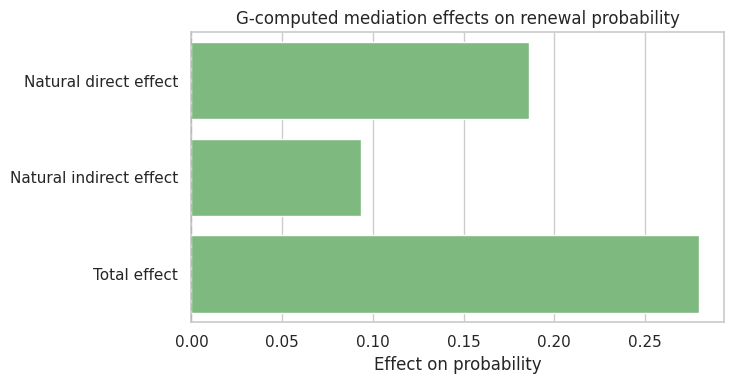

In [16]:
decomp_binary = pd.DataFrame(
    {
        "component": ["Natural direct effect", "Natural indirect effect", "Total effect"],
        "effect": [
            binary_effects["Natural direct effect NDE(0)"],
            binary_effects["Natural indirect effect NIE(1)"],
            binary_effects["Total effect"],
        ],
    }
)

fig, ax = plt.subplots(figsize=(7.5, 4))
sns.barplot(data=decomp_binary, x="effect", y="component", color="#74c476", ax=ax)
ax.axvline(0, color="#444444", linestyle="--")
ax.set_title("G-computed mediation effects on renewal probability")
ax.set_xlabel("Effect on probability")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


The decomposition depends on the fitted mediator and outcome models, plus the identification assumptions. It is not a purely mechanical property of the data.


## 9. Simulation 3: Unmeasured Mediator-Outcome Confounding

Now we create an unmeasured variable $U$ that affects both the mediator and the outcome.

Examples:

- customer motivation affects activation and renewal,
- disease severity affects treatment adherence and health,
- teacher quality affects student engagement and test scores,
- manager skill affects adoption and team performance.

Treatment is still randomized. The total effect remains easy to estimate. The mediation decomposition becomes biased if $U$ is omitted.


In [17]:
def simulate_unmeasured_confounding(u_strength, seed=555, n=7000):
    rng = np.random.default_rng(seed)
    x = rng.normal(0, 1, size=n)
    u = rng.normal(0, 1, size=n)
    treatment = rng.binomial(1, 0.5, size=n)
    mediator = 0.3 + 0.80 * treatment + 0.55 * x + u_strength * u + rng.normal(0, 1.0, size=n)
    outcome = 1.5 + 1.10 * treatment + 1.50 * mediator + 0.45 * x + u_strength * u + rng.normal(0, 1.2, size=n)
    return pd.DataFrame(
        {
            "x": x,
            "u": u,
            "treatment": treatment,
            "mediator": mediator,
            "outcome": outcome,
        }
    )


def product_mediation(data, include_u=False):
    covars = "x + u" if include_u else "x"
    m = smf.ols(f"mediator ~ treatment + {covars}", data=data).fit()
    y = smf.ols(f"outcome ~ treatment + mediator + {covars}", data=data).fit()
    total = smf.ols(f"outcome ~ treatment + {covars}", data=data).fit()
    return pd.Series(
        {
            "indirect": m.params["treatment"] * y.params["mediator"],
            "direct": y.params["treatment"],
            "total": total.params["treatment"],
        }
    )


confounding_rows = []
for strength in np.linspace(0, 1.4, 8):
    sim = simulate_unmeasured_confounding(strength, seed=1000 + int(strength * 100))
    omitted = product_mediation(sim, include_u=False)
    oracle = product_mediation(sim, include_u=True)
    confounding_rows.append(
        {
            "u_strength": strength,
            "omitted_indirect": omitted["indirect"],
            "omitted_direct": omitted["direct"],
            "omitted_total": omitted["total"],
            "oracle_indirect": oracle["indirect"],
            "oracle_direct": oracle["direct"],
            "oracle_total": oracle["total"],
        }
    )

confounding_results = pd.DataFrame(confounding_rows)
confounding_results


,u_strength,omitted_indirect,omitted_direct,omitted_total,oracle_indirect,oracle_direct,oracle_total
0,0.000,1.196,1.039,2.235,1.196,1.039,2.235
1,0.200,1.222,1.018,2.240,1.187,1.048,2.235
2,0.400,1.349,1.008,2.357,1.239,1.137,2.376
3,0.600,1.443,0.873,2.316,1.208,1.097,2.305
4,0.800,1.549,0.800,2.349,1.216,1.102,2.319
5,1.000,1.595,0.703,2.297,1.191,1.123,2.314
6,1.200,1.656,0.626,2.282,1.216,1.117,2.333
7,1.400,1.646,0.549,2.195,1.181,1.103,2.284


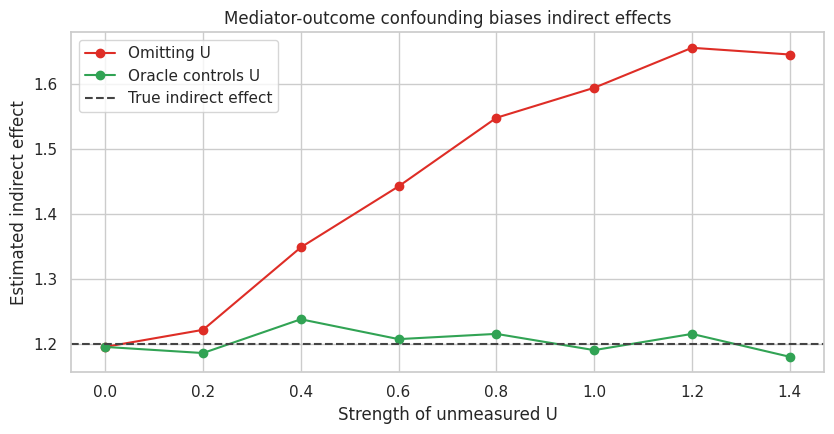

In [18]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(
    confounding_results["u_strength"],
    confounding_results["omitted_indirect"],
    marker="o",
    label="Omitting U",
    color="#de2d26",
)
ax.plot(
    confounding_results["u_strength"],
    confounding_results["oracle_indirect"],
    marker="o",
    label="Oracle controls U",
    color="#31a354",
)
ax.axhline(0.80 * 1.50, color="#444444", linestyle="--", label="True indirect effect")
ax.set_title("Mediator-outcome confounding biases indirect effects")
ax.set_xlabel("Strength of unmeasured U")
ax.set_ylabel("Estimated indirect effect")
ax.legend()
plt.tight_layout()
plt.show()


The total effect remains stable because treatment is randomized. The indirect and direct effects shift when $U$ is omitted because the mediator-outcome relationship is confounded.

This is the core warning:

> Randomized treatment protects the total effect. It does not automatically protect the mediation decomposition.


## 10. Post-Treatment Confounders

Sometimes treatment changes a variable $L$ that then affects both the mediator and the outcome.

Example:

- treatment: onboarding call,
- post-treatment confounder: account manager follow-up intensity,
- mediator: product activation,
- outcome: renewal.

If follow-up intensity is affected by treatment and affects both activation and renewal, ordinary mediation formulas are not enough.


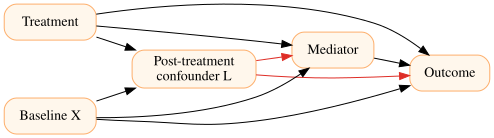

In [19]:
dot = Digraph("post_treatment_confounder", graph_attr={"rankdir": "LR"})
dot.attr("node", shape="box", style="rounded,filled", fillcolor="#fff7ec", color="#fdae6b")

dot.node("T", "Treatment")
dot.node("L", "Post-treatment\nconfounder L")
dot.node("M", "Mediator")
dot.node("Y", "Outcome")
dot.node("X", "Baseline X")

dot.edge("T", "L")
dot.edge("T", "M")
dot.edge("T", "Y")
dot.edge("L", "M", color="#de2d26")
dot.edge("L", "Y", color="#de2d26")
dot.edge("M", "Y")
dot.edge("X", "L")
dot.edge("X", "M")
dot.edge("X", "Y")

dot


Adjusting for $L$ can block part of the treatment effect and create a different estimand. Not adjusting for $L$ can leave mediator-outcome confounding. This is why advanced mediation often needs stronger designs, longitudinal g-methods, or a different causal question.


## 11. Controlled Direct Effects

Natural direct and indirect effects ask about the mediator value each unit would naturally have under treatment or control. Controlled direct effects ask a different question:

$$
CDE(m) = E[Y(1,m) - Y(0,m)]
$$

This is useful when the mediator can be set or standardized by intervention.

Examples:

- compare two onboarding scripts while fixing activation support at the same level,
- estimate the effect of a pricing message if discount exposure were set to zero,
- compare medical treatment regimes under a fixed adherence level,
- estimate the direct effect of a policy if a downstream service were provided equally.


In [20]:
controlled_rows = []
for m_value in [-1, 0, 1, 2]:
    # In the clean linear model, CDE is constant because there is no T x M interaction.
    y_t1 = 2.0 + 1.15 * 1 + 1.55 * m_value
    y_t0 = 2.0 + 1.15 * 0 + 1.55 * m_value
    controlled_rows.append(
        {
            "fixed_mediator_value": m_value,
            "controlled_direct_effect": y_t1 - y_t0,
        }
    )

controlled_direct = pd.DataFrame(controlled_rows)
controlled_direct


,fixed_mediator_value,controlled_direct_effect
0,-1,1.150
1,0,1.150
2,1,1.150
3,2,1.150


In models with treatment-mediator interaction, the controlled direct effect can vary by the mediator value. That is not a nuisance; it may be the scientific question.


## 12. Mediation Report Template

A mediation readout should be more cautious than a standard experiment readout.


In [21]:
mediation_report = pd.DataFrame(
    [
        {
            "section": "Causal question",
            "what_to_report": "State the mediator, outcome, population, and time order.",
            "example": "How much of onboarding's renewal effect operates through 7-day activation?",
        },
        {
            "section": "Total effect",
            "what_to_report": "Report the ordinary treatment effect first.",
            "example": "Assignment increased renewal by 6.2 percentage points.",
        },
        {
            "section": "Pathway estimands",
            "what_to_report": "Define direct, indirect, controlled, or natural effects explicitly.",
            "example": "We estimate NDE(0) and NIE(1) on the probability scale.",
        },
        {
            "section": "Identification",
            "what_to_report": "List assumptions beyond treatment randomization.",
            "example": "No unmeasured mediator-outcome confounding conditional on X.",
        },
        {
            "section": "Estimation",
            "what_to_report": "Describe mediator model, outcome model, interactions, and uncertainty method.",
            "example": "Logistic mediator and outcome models with g-computation and bootstrap CIs.",
        },
        {
            "section": "Sensitivity",
            "what_to_report": "Show how conclusions change under violations of assumptions.",
            "example": "Indirect effect would be materially smaller under moderate residual confounding.",
        },
        {
            "section": "Action",
            "what_to_report": "Translate mechanism into a decision without overclaiming.",
            "example": "Invest in activation support, but validate with a mediator manipulation test.",
        },
    ]
)

mediation_report


,section,what_to_report,example
0,Causal question,"State the mediator, outcome, population, and t...",How much of onboarding's renewal effect operat...
1,Total effect,Report the ordinary treatment effect first.,Assignment increased renewal by 6.2 percentage...
2,Pathway estimands,"Define direct, indirect, controlled, or natura...",We estimate NDE(0) and NIE(1) on the probabili...
3,Identification,List assumptions beyond treatment randomization.,No unmeasured mediator-outcome confounding con...
4,Estimation,"Describe mediator model, outcome model, intera...",Logistic mediator and outcome models with g-co...
5,Sensitivity,Show how conclusions change under violations o...,Indirect effect would be materially smaller un...
6,Action,Translate mechanism into a decision without ov...,"Invest in activation support, but validate wit..."


## 13. Decision Memo Example

The strongest mediation conclusion is rarely "we proved the mechanism." A better conclusion is:

- the total effect is real under the design,
- the mediator explains a plausible share under explicit assumptions,
- the mechanism claim is sensitive or robust to specific threats,
- the next decision should either act on the mechanism or test it more directly.


In [22]:
total_effect = summary.loc["Total effect", "point_estimate"]
indirect_effect = summary.loc["Indirect effect", "point_estimate"]
direct_effect = summary.loc["Direct effect", "point_estimate"]
prop_mediated = summary.loc["Proportion mediated", "point_estimate"]

memo = f'''
### Mediation Readout: Onboarding Through Activation

**Decision question:** should the team invest in activation support as the main mechanism behind onboarding impact?

**Total effect:** assignment to onboarding increased the outcome by **{total_effect:,.2f}** units in the simulated experiment.

**Mediation estimate:** under the linear mediation model and sequential ignorability assumptions,
the indirect pathway through activation is **{indirect_effect:,.2f}** units and the direct pathway is
**{direct_effect:,.2f}** units.

**Proportion mediated:** the estimated mediated share is **{prop_mediated:.1%}**.
This should be interpreted cautiously because proportions are unstable when total effects are small.

**Main identifying risk:** treatment was randomized, but activation was not independently randomized.
The decomposition assumes no unmeasured activation-outcome confounding after conditioning on measured covariates.

**Recommendation:** treat activation as a strong candidate mechanism, not as proven.
If the mechanism will drive product investment, run a follow-up design that manipulates activation support more directly or strengthens measurement of mediator-outcome confounders.
'''

display(Markdown(memo))



### Mediation Readout: Onboarding Through Activation

**Decision question:** should the team invest in activation support as the main mechanism behind onboarding impact?

**Total effect:** assignment to onboarding increased the outcome by **2.46** units in the simulated experiment.

**Mediation estimate:** under the linear mediation model and sequential ignorability assumptions,
the indirect pathway through activation is **1.32** units and the direct pathway is
**1.14** units.

**Proportion mediated:** the estimated mediated share is **53.7%**.
This should be interpreted cautiously because proportions are unstable when total effects are small.

**Main identifying risk:** treatment was randomized, but activation was not independently randomized.
The decomposition assumes no unmeasured activation-outcome confounding after conditioning on measured covariates.

**Recommendation:** treat activation as a strong candidate mechanism, not as proven.
If the mechanism will drive product investment, run a follow-up design that manipulates activation support more directly or strengthens measurement of mediator-outcome confounders.


## 14. Common Failure Modes

- **Calling mediator adjustment a direct effect without assumptions.**
- **Controlling for a mediator when the goal is the total effect.**
- **Ignoring mediator-outcome confounding.**
- **Reporting a proportion mediated when the total effect is tiny or uncertain.**
- **Using post-treatment confounders as ordinary controls.**
- **Treating a noisy proxy mediator as the true mechanism.**
- **Claiming a mechanism from observational mediator variation after only treatment was randomized.**
- **Forgetting time order: the mediator must occur before the outcome.**


## 15. Exercises

1. In the linear simulation, add a treatment-mediator interaction. How does the product-of-coefficients interpretation change?
2. In the binary simulation, remove the interaction term from the outcome model. Compare the g-computed effects.
3. In the unmeasured confounding simulation, change the sign of $U$'s effect on the outcome. What happens to the indirect effect?
4. Add measurement error to the mediator. How does the estimated mediated pathway change?
5. Create a post-treatment confounder $L$ affected by treatment. Compare estimates that adjust and do not adjust for $L$.
6. Write a mediation readout for a marketing campaign where email opens are the mediator and purchases are the outcome.


## 16. Key Takeaways

- Mediation analysis asks how an effect happens, not only whether it happens.
- The total effect is easier to identify than direct and indirect effects.
- Natural direct and indirect effects use cross-world counterfactuals and require strong assumptions.
- Randomizing treatment does not randomize the mediator.
- Linear product-of-coefficients mediation is a special case, not the whole field.
- G-computation lets us define mediation effects on meaningful scales with nonlinear models and interactions.
- Sensitivity analysis and careful language are essential because mediator-outcome confounding is often the main threat.


## References

Imai, K., Keele, L., & Tingley, D. (2010). A general approach to causal mediation analysis. *Psychological Methods, 15*(4), 309-334. https://doi.org/10.1037/a0020761

Imai, K., Keele, L., & Yamamoto, T. (2010). Identification, inference and sensitivity analysis for causal mediation effects. *Statistical Science, 25*(1), 51-71. https://doi.org/10.1214/10-STS321

Imai, K., Tingley, D., & Yamamoto, T. (2013). Experimental designs for identifying causal mechanisms. *Journal of the Royal Statistical Society: Series A, 176*(1), 5-51. https://doi.org/10.1111/j.1467-985X.2012.01032.x

Robins, J. M., & Greenland, S. (1992). Identifiability and exchangeability for direct and indirect effects. *Epidemiology, 3*(2), 143-155. https://doi.org/10.1097/00001648-199203000-00013

VanderWeele, T. J. (2016). Explanation in causal inference: developments in mediation and interaction. *International Journal of Epidemiology, 45*(6), 1904-1908. https://doi.org/10.1093/ije/dyw277

VanderWeele, T. J., & Vansteelandt, S. (2010). Odds ratios for mediation analysis for a dichotomous outcome. *American Journal of Epidemiology, 172*(12), 1339-1348. https://doi.org/10.1093/aje/kwq332
